In [19]:
from astroplan.plots import plot_airmass
from astropy.coordinates import SkyCoord
from astroplan import FixedTarget
from astropy.time import Time
from astroplan import Observer
from astroplan.plots import plot_airmass
from astroplan.plots import plot_parallactic
import matplotlib.pyplot as plt
from matplotlib import dates
import numpy as n
import astropy.units as u
import etc_data
import etc_routines

from astropy.io import fits
from photutils.aperture import aperture_photometry, CircularAperture
from astropy import constants
import xlrd
#import etc_data
#import etc_routines
import analysis
from scipy.integrate import nquad
from astropy.modeling.functional_models import Gaussian2D
from scipy.ndimage import gaussian_filter
#%matplotlib notebook

In [20]:
# constants
kb = constants.k_B.value #[J/K]
c = constants.c.value    #[m/s]
h = constants.h.value    #[J/s]   
e_charge = constants.e   #[Coloumbs]
microns2m = 1e-6         #[microns/meters]
deg2rad = 0.0174533

#telescope parameters
aperture = 6.5#/2                            #[meters/radius]
#distances = n.array([20])# 2, 3, 4, 5, 10, 15, 20, 40])    #pc
distance = 51.5
exp_time = 1#seconds
duration = 20#20#.25#.0006#.25 #hours

#directories


save_dir = 'simulated_data_R10/'

image_number = int(duration * 60 * 60 / exp_time)
image_numbers = n.arange(image_number)
deg =  -180 * (n.arange(image_number)/image_number)
print('image number:', str(image_number))
print('duration:', str(duration))

image number: 72000
duration: 20


In [21]:
#get rotation

observer = Observer.at_site('LBT')
target_name = "Kapp And B"
ra = '23h40m24.50773s'
dec = '44d20m02.1586696s'

pa1 = -45

coordinates = SkyCoord(ra, dec , frame='icrs')
target_info = FixedTarget(name=target_name, coord=coordinates)

time = Time(['2026-10-01 0:00:00'])
dt = n.arange(0,image_number)* exp_time
times = time + (dt * u.second)
parallactic_angles = observer.parallactic_angle(times, target_info).deg

position_angle1 = pa1 + n.zeros(len(parallactic_angles))

total_angle1 = position_angle1 + parallactic_angles

overshoot = n.where(total_angle1<0)
total_angle1[overshoot] += 360

airmasses = observer.altaz(times, target_info).secz 
airmasses = airmasses.value

good = n.where((airmasses >= 1.) & (airmasses <= 2.06))
bad = n.where((airmasses < 1.) | (airmasses > 2.06))


parallactic_angles = parallactic_angles[good]
airmasses = airmasses[good] 
total_angle1 = total_angle1[good]
image_numbers = image_numbers[good]
dt = dt[good]

In [22]:
airmasses

array([2.05989665, 2.05971388, 2.05953114, ..., 2.05953746, 2.0597202 ,
       2.05990298], shape=(38174,))

In [23]:
parallactic_angles

array([-71.40092124, -71.40330788, -71.40569452, ...,  71.02226138,
        71.01987526,  71.01748913], shape=(38174,))

In [24]:
len(image_numbers)

38174

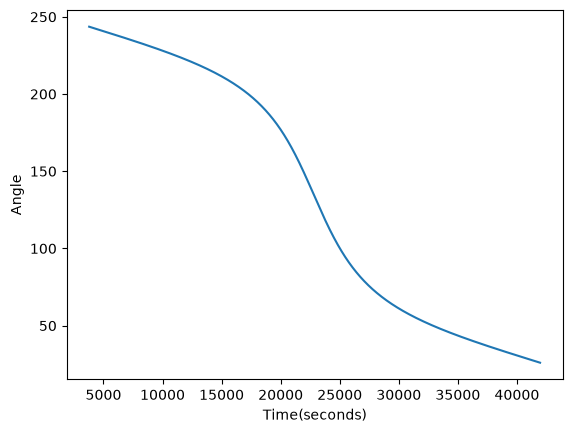

In [25]:
plt.figure('total angle')
plt.plot(dt, total_angle1)
plt.ylabel('Angle')
plt.xlabel('Time(seconds)')
plt.show()

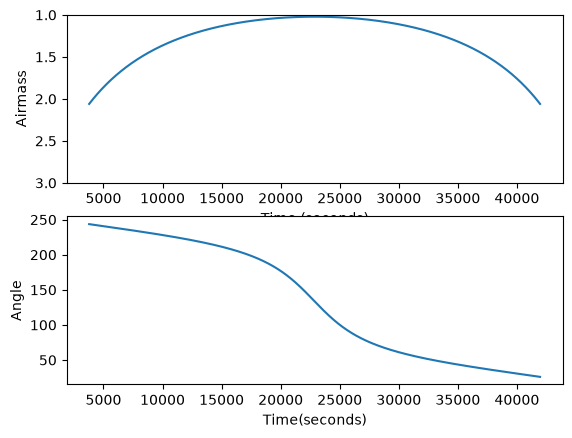

In [26]:
plt.figure('Airmass')
plt.subplot(211)
plt.plot(dt, airmasses)
plt.ylim([3,1])
plt.ylabel('Airmass')
plt.xlabel('Time (seconds)')

plt.subplot(212)
plt.plot(dt, total_angle1)
plt.ylabel('Angle')
plt.xlabel('Time(seconds)')
plt.show()

In [27]:
start_lam

7.5

In [28]:
end_lam

14

In [29]:
del_R

1.075

In [36]:
filter_wavelengths

NameError: name 'filter_wavelengths' is not defined

In [31]:
n.linspace(0, 10, 5)

array([ 0. ,  2.5,  5. ,  7.5, 10. ])

In [32]:
n.arange(0.1,10,2.1)

array([0.1, 2.2, 4.3, 6.4, 8.5])

In [33]:
filter_info

[(array([0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
         0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.6, 0.6, 0.6, 0.6, 0.6,
         0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6,
         0.6, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
         0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ]),
  array([6.425  , 6.47875, 6.5325 , 6.58625, 6.64   , 6.69375, 6.7475 ,
         6.80125, 6.855  , 6.90875, 6.9625 , 7.01625, 7.07   , 7.12375,
         7.1775 , 7.23125, 7.285  , 7.33875, 7.3925 , 7.44625, 7.5    ,
         7.55375, 7.6075 , 7.66125, 7.715  , 7.76875, 7.8225 , 7.87625,
         7.93   , 7.98375, 8.0375 , 8.09125, 8.145  , 8.19875, 8.2525 ,
         8.30625, 8.36   , 8.41375, 8.4675 , 8.52125, 8.575  , 8.62875,
         8.6825 , 8.73625, 8.79   , 8.84375, 8.8975 , 8.95125, 9.005  ,
         9.05875, 9.1125 , 9.16625, 9.22   , 9.27375, 9.3275 , 9.38125,
         9.435  , 9.48875, 9.5425 , 9.59625, 9.65   ])),
 (array([0. , 0

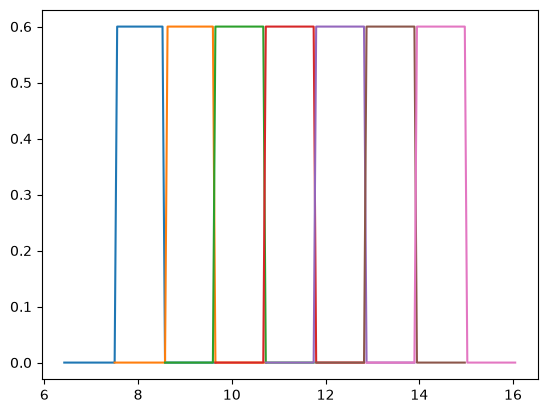

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (7, 2) + inhomogeneous part.

In [34]:
Rs =10
start_lam = 7.5
end_lam = 14
central_wavelength = (start_lam+end_lam)/2
del_R = central_wavelength/Rs  #spacing of wavelength element
filter_spacing = n.arange(start_lam, end_lam, del_R)

filter_info = [None] * len(filter_spacing)

plt.figure('Filter/Spacing')

for i, filter_start in enumerate(filter_spacing):
    
    filter_lam = n.arange(filter_start-del_R,filter_start+2*del_R,del_R/20)
    response = n.where( (filter_lam > (filter_start)) & (filter_lam < (filter_start + del_R)) )
    filter_t = n.zeros(filter_lam.shape)
    filter_t[response] = .6
    
    
    plt.plot(filter_lam, filter_t)
    
    filter_info[i] = filter_t, filter_lam
plt.show()

#n.save(save_dir + 'filter_info', filter_info)
n.save(save_dir + 'filter_info', n.array(filter_info, dtype=object), allow_pickle=True)

In [63]:
plate_scale = 0.1 #[arcseonds/pix]

x_pix = 35
y_pix = 35

star_x = x_pix/2
star_y = y_pix/2

planet_r1 = 1.1/plate_scale

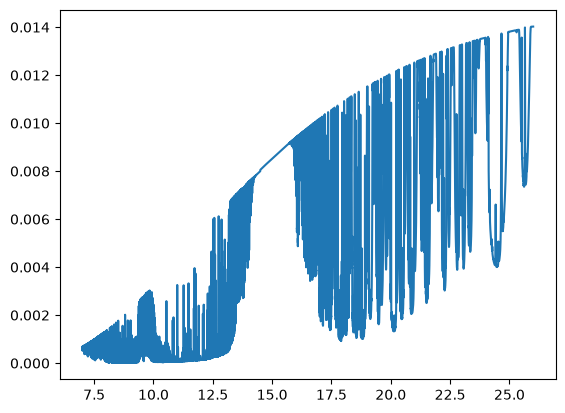

In [64]:
 #load mid-infrared transmission
        
#1.5 airmass #1.6 pwv - #mktrans_nq_16_15.dat
mir_transmission = n.genfromtxt('/Users/zen/data/instrument_filters/infrared_transmission_data/mktrans_nq_16_20.dat')
mir_t_lam = mir_transmission[:,0] #wavelength (microns)
mir_t = mir_transmission[:,1] #transmission (fraction)

mir_sky_t = mir_t, mir_t_lam
    
    
#Import the sky emission #1.5 airmass #1.6 pwv
sky_flux, sky_lam = etc_data.mir_sky_emission() #phot/s/nm/arcsec^2/m^2, #angstroms

sky_flux *= n.pi * (aperture**2)                #phot/s/nm/arcsec^2
sky_flux *= plate_scale**2                      #phot/s/nm
sky_flux *= (1./1e-9)  #*(nm/m)       ->        #phot/s/m
sky_flux *= ((sky_lam * 1e-10)**2)/c            #phot/s/Hz
            
        
#sky_flux *= (1./100)**2   #*(m/cm)**2    ->       #phot/s/nm/arcsec^2/cm^2
#sky_flux *= (1./1e-9)     #*(nm/m)       ->       #phot/s/m/cm^2/arcsec^2
#sky_flux *= ((sky_lam * 1e-10)**2)/c            #erg/s/cm^2/Hz/arcsec^2
#sky_flux *= (h*c / (sky_lam * 1e-10))           #joules/s/m/cm^2/arcsec^2
#sky_flux *= 1e7                                 #erg/s/m/cm^2/arcsec^2   
#sky_flux *= ((sky_lam * 1e-10)**2)/c            #erg/s/cm^2/Hz/arcsec^2

sky_lam /= 10000 #microns

plt.figure('sky')
plt.plot(sky_lam, sky_flux)
plt.show()

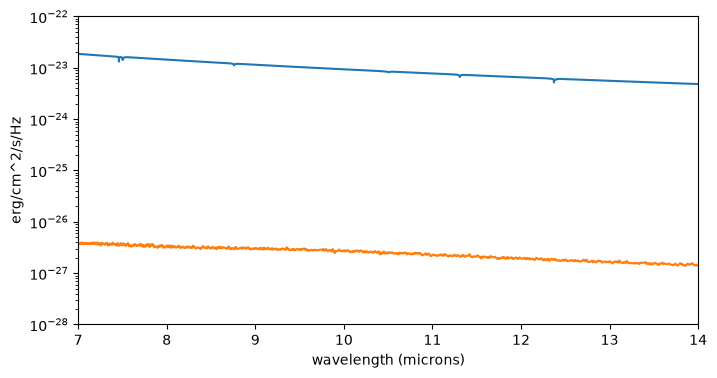

In [65]:
#star data out
star_data = fits.getdata('/Users/zen/data/cal_spec_files/ksi2ceti_mod_006.fits')
star_lam = star_data['WAVELENGTH'] #Angstroms
star_flux = star_data['FLUX'] # erg/s/cm^2/A

star_flux /= 1e-10  # erg/s/cm^2/m
star_flux *= ((star_lam * 1e-10)**2)/c  #erg/s/cm^2/Hz

star_lam /= 10000 #microns

star_flux *= (( 60.4005 / distance)**2)
    
    
#target info
#brown dwarf spectrum
model_dir = '/Users/zen/data/models/sonora_diamondback/spectra/t2000g100f1_m0.0_co1.0.spec'
gas_giant_data = n.genfromtxt(model_dir, skip_header = 3)
gas_giant_lam = gas_giant_data[:,0]  #wavelength (microns)
gas_giant_flux = gas_giant_data[:,1] #(W/m^2/m)

gas_giant_flux *= 1e7                             #erg/s/m^2/m
gas_giant_flux *= (1/100**2)                      #erg/s/cm^2/m
gas_giant_flux *= ((gas_giant_lam * 1e-6)**2)/c   #erg/s/cm^2/Hz

order = n.argsort(gas_giant_lam)
gas_giant_lam = gas_giant_lam[order]
gas_giant_flux = gas_giant_flux[order]

r_jup2pc = 2.3169e-9
    
#scale to distance
planet_radius = 1.2

gas_giant_flux *= ((planet_radius * r_jup2pc / distance)**2)


#---------------------------------------------------



plt.figure('spectra', figsize = (8, 4))
plt.plot(star_lam, star_flux)
#plt.plot(gas_giant_lam, gas_giant_flux)
#plt.plot(gas_giant_lam2, gas_giant_flux2)
#plt.plot(gas_giant_lam3, gas_giant_flux3)
#plt.plot(gas_giant_lam4, gas_giant_flux4)

plt.plot(gas_giant_lam, gaussian_filter(gas_giant_flux, 10))
#plt.plot(gas_giant_lam2, gaussian_filter(gas_giant_flux2, 10))
#plt.plot(gas_giant_lam3, gaussian_filter(gas_giant_flux3, 10))
#plt.plot(gas_giant_lam4, gaussian_filter(gas_giant_flux4, 10))

plt.yscale('log')
plt.ylabel('erg/cm^2/s/Hz')
plt.xlabel('wavelength (microns)')
plt.xlim([7, 14])
plt.ylim([1e-28, 1e-22])
plt.show()

In [67]:
wavelengths = n.zeros(len(filter_info))

for filter_no, filter_data in enumerate(filter_info):
    
    print('Filter Number:' + str(filter_no))
    print('Distance ' +  str(distance) + ' pc')
    print('EXP TIME ' + str(exp_time/60/60) + ' hours') 
    
    
    #detector characteristics
    read_noise = 133           #[e-]
    dark_current = 2.4e5         #[e-/pix/s]
    #saturation = 16000        #[e-/pixel]
    
    pixel_size = 18.    #[microns/pix]
    #plate_scale = (17.9* 1e-3)*4 #[arcseonds/pix]
    image_scale = pixel_size / plate_scale   #[microns/arcsecond] 

    #detector quantum efficiency
    detector_qe = .65 

    filter_t, filter_lam, = filter_data
    
    
    #calculate flux in filter  
    
    
    sky_flux_out, sky_lam_out = etc_routines.pass_through_transmission(sky_flux, sky_lam, mir_sky_t) #phot/s/Hz
    sky_flux_out, sky_lam_out = etc_routines.pass_through_transmission(sky_flux_out, sky_lam_out, filter_data) #phot/s/Hz 
    
    #sky_flux_out, sky_lam_out = etc_routines.pass_through_transmission(sky_flux, sky_lam, mir_sky_t) #erg/s/cm^2/Hz/arcsec^2
    #sky_flux_out, sky_lam_out = etc_routines.pass_through_transmission(sky_flux_out, sky_lam_out, filter_data) #erg/s/cm^2/Hz/arcsec^2
    
    gas_giant_flux_out, gas_giant_lam_out = etc_routines.pass_through_transmission(gas_giant_flux, gas_giant_lam, mir_sky_t) #erg/s/cm^2/Hz
    gas_giant_flux_out, gas_giant_lam_out = etc_routines.pass_through_transmission(gas_giant_flux_out, gas_giant_lam_out, filter_data) #erg/s/cm^2/Hz]
   
 
    star_flux_out, star_lam_out = etc_routines.pass_through_transmission(star_flux, star_lam, mir_sky_t) #erg/s/cm^2/Hz
    star_flux_out, star_lam_out = etc_routines.pass_through_transmission(star_flux_out, star_lam_out, filter_data) #erg/s/cm^2/Hz]
    
    #----------
    
    #accounting for detector QE
    sky_flux_out *= detector_qe
    gas_giant_flux_out *= detector_qe
    star_flux_out *= detector_qe

    #photons captured from the source based on aperture
    #sky_flux_out *= n.pi * ((aperture * 100 )**2)    #[erg s^-1 Hz^-1 arcsec^-2]
    #sky_flux_out /= image_scale**2            #[erg s^-1 Hz^-1] sky per pixel

    gas_giant_flux_out *= n.pi * ((aperture * 100 )**2)    #[erg s^-1 Hz^-1]
    star_flux_out *= n.pi * ((aperture * 100 )**2)    #[erg s^-1 Hz^-1]
    

    sky_flux_photon_rate = sky_flux_out #[phtons s^-1 Hz^-1] sky per pixel
    #sky_flux_out/ (1e7 * h * c/ ( sky_lam_out * 1e-6 ))          #[phtons s^-1 Hz^-1] sky per pixel
    gas_giant_flux_photon_rate = gas_giant_flux_out/ (1e7 * h * c/ ( gas_giant_lam_out * 1e-6 ))          #[phtons s^-1 Hz^-1]
    star_flux_photon_rate = star_flux_out/ (1e7 * h * c/ ( star_lam_out * 1e-6 ))          #[phtons s^-1 Hz^-1] 

    
    good_sky = n.where(n.isnan(sky_flux_photon_rate)== False)
    sky_flux_photon_rate = sky_flux_photon_rate[good_sky]
    sky_lam_out = sky_lam_out[good_sky]
    
    good_gas_giant = n.where(n.isnan(gas_giant_flux_photon_rate)== False)
    gas_giant_flux_photon_rate = gas_giant_flux_photon_rate[good_gas_giant]
    gas_giant_lam_out = gas_giant_lam_out[good_gas_giant]
    
    #-------------------------------------------------------------#
    y = gas_giant_flux_photon_rate
    x = c/(gas_giant_lam_out * 1e-6)
    order = n.argsort(x)
    y = y[order]
    x = x[order]

    gas_giant_photons = n.trapezoid( y,x ) * exp_time  #[phtons]
    print('gas_giant photons 1:', gas_giant_photons)

    #-------------------------------------------------------------#

    y = sky_flux_photon_rate
    x = c/(sky_lam_out * 1e-6)
    order = n.argsort(x)
    y = y[order]
    x = x[order]

    sky_photons = n.trapezoid( y,x ) * exp_time  #[phtons]|
    print('sky photons:', sky_photons)
    
    
    y = star_flux_photon_rate
    x = c/(star_lam_out * 1e-6)
    order = n.argsort(x)
    y = y[order]
    x = x[order]

    star_photons = n.trapezoid( y,x ) * exp_time  #[phtons]
    
    print('star photons:', star_photons)
    
    
    #making detector image
    central_wavelength = n.average(filter_lam, weights=filter_t)
    wavelengths[filter_no] = central_wavelength
    first_zero = 1.22 * (central_wavelength * 1e-6)/(aperture * 2) # 1.22(lam/diamter) #radians
    first_zero *= 206265 #arcseconds
    
    ydim = n.arange(y_pix)
    xdim = n.arange(x_pix)
    xgrid, ygrid = n.meshgrid(xdim,ydim)
    
    for image_no in n.arange(len(image_numbers)):  
        
        detector = n.zeros((y_pix, x_pix)) # detector image
        bkg = n.zeros((y_pix, x_pix)) # detector image 
        
        #planet 1
        planet_x1 = star_x + planet_r1 * n.cos((total_angle1[image_no])* deg2rad)
        planet_y1 = star_y + planet_r1 * n.sin((total_angle1[image_no])* deg2rad)
        
    
        #sky image
        sky = n.random.poisson( lam = sky_photons, size = n.shape(detector)) 
        sky_bkg = n.random.poisson( lam = sky_photons, size = n.shape(detector)) 
    

        x_sigma = first_zero/plate_scale
        y_sigma = first_zero/plate_scale
        #create gas_giant image 1
        gas_giant_amplitude = gas_giant_photons/( 2 * n.pi * x_sigma * y_sigma)
        gas_giant_image_pattern_f = Gaussian2D(amplitude=gas_giant_amplitude, x_mean=planet_x1, y_mean=planet_y1, x_stddev=x_sigma, y_stddev=y_sigma)                                     
        gas_giant_image_pattern = gas_giant_image_pattern_f(xgrid, ygrid)
        gas_giant_image = n.random.poisson( lam = gas_giant_image_pattern, size = n.shape(gas_giant_image_pattern))
        gas_giant_image1 = gas_giant_image.astype(float) 
        
        star_amplitude = star_photons/( 2 * n.pi * x_sigma * y_sigma)
        star_image_pattern_f = Gaussian2D(amplitude=star_amplitude, x_mean = star_x, y_mean = star_y, x_stddev=x_sigma, y_stddev=y_sigma)                                     
        star_image_pattern = star_image_pattern_f(xgrid, ygrid)
        star_image = n.random.poisson( lam = star_image_pattern, size = n.shape(star_image_pattern))
        star_image = star_image.astype(float)             

        
        detector += sky #* 200
        detector += dark_current * exp_time
        #detector += read_noise**2
        detector += gas_giant_image1 
        detector += star_image
        
        #making background ir image
        bkg += sky_bkg #* 20000000
    
        #detector_hdu = fits.ImageHDU()
        #detector_hdu.data = detector
        #detector_hdu.header['WAV'] = central_wavelength
        #detector_hdu.header['SCALE'] = plate_scale
        #detector_hdu.header['ANG'] = deg[image_no]
        #detector_hdu.writeto(save_dir + 'raw_day1/raw_'+str(filter_no)+'_'+str(image_no)+'.fits', overwrite = True)
        
        #bkg_hdu = fits.ImageHDU()
        #bkg_hdu.data = bkg
        #bkg_hdu.header['WAV'] = central_wavelength
        #bkg_hdu.header['SCALE'] = plate_scale
        #bkg_hdu.header['ANG'] = deg[image_no]
        #bkg_hdu.writeto(save_dir + '/bkg/bkg_'+str(filter_no)+'_'+str(image_no)+'.fits', overwrite = True)
        
        detector_sub_bkg_hdu = fits.PrimaryHDU()
        detector_sub_bkg_hdu.data = detector - bkg
        detector_sub_bkg_hdu.header['WAV'] = central_wavelength
        detector_sub_bkg_hdu.header['SCALE'] = plate_scale
        detector_sub_bkg_hdu.header['ANG'] = parallactic_angles[image_no]
        detector_sub_bkg_hdu.writeto(save_dir + 'reduced_day1/im_'+str(filter_no)+'_'+str(image_no)+'.fits.gz', overwrite = True)
        
        print('image no :' + str(image_no))
    

Filter Number:0
Distance 51.5 pc
EXP TIME 0.0002777777777777778 hours
gas_giant photons 1: 19387.193277579234
sky photons: 218861690.58522698
star photons: 82993089.33967958
image no :0
image no :1
image no :2
image no :3
image no :4
image no :5
image no :6
image no :7
image no :8
image no :9
image no :10
image no :11
image no :12
image no :13
image no :14
image no :15
image no :16
image no :17
image no :18
image no :19
image no :20
image no :21
image no :22
image no :23
image no :24
image no :25
image no :26
image no :27
image no :28
image no :29
image no :30
image no :31
image no :32
image no :33
image no :34
image no :35
image no :36
image no :37
image no :38
image no :39
image no :40
image no :41
image no :42
image no :43
image no :44
image no :45
image no :46
image no :47
image no :48
image no :49
image no :50
image no :51
image no :52
image no :53
image no :54
image no :55
image no :56
image no :57
image no :58
image no :59
image no :60
image no :61
image no :62
image no :63
imag

In [ ]:
n.trap